In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
import sys

print("at directory:", os.getcwd())
print("changing to root directory")
os.chdir("..")
print("at directory:", os.getcwd())

at directory: /n/home13/wcarvalho/projects/preplay-human/analysis_notebooks
changing to root directory
at directory: /n/home13/wcarvalho/projects/preplay-human


In [3]:
# ON SERVER
RESULTS_DIR = "/n/holylfs06/LABS/kempner_fellow_wcarvalho"
USER_RESULTS_DIR = os.path.join(
  RESULTS_DIR, "results/human_dyna_craftax/user_data/exps"
)

In [4]:
# # ON COMPUTER
# RESULTS_DIR ='/Users/wilka/git/research/'
# USER_RESULTS_DIR = os.path.join(RESULTS_DIR, 'results/human_dyna_craftax/user_data/exps')

In [5]:
# from analysis.craftax_download_data import download_user_files
# import craftax_experiment_configs as config

# bucket_name = config.BUCKET_NAME  # google cloud
# bucket_prefix = "data/"
# # pattern = "data/data_user=*_name=r0-v2*debug=0.json"
# human_data_pattern = "data/*v1*debug=0.json"
# # human_data_pattern = "data/*4220*.json"


# download_user_files(
#     bucket_name=bucket_name,
#     prefix=bucket_prefix,
#     pattern=human_data_pattern,
#     destination_folder=USER_RESULTS_DIR)

# Get files

In [7]:
from glob import glob

files = f"{USER_RESULTS_DIR}/*2635592883*.json"
valid_files = list(set(glob(files)))
len(valid_files)

1

In [9]:
file = valid_files[0]
file

'/n/holylfs06/LABS/kempner_fellow_wcarvalho/results/human_dyna_craftax/user_data/exps/user=2635592883_worker=A6MWJK1YEY5L2_name=craftax_v3-paths-r0-m0_debug=0.json'

In [13]:
from nicewebrl.utils import read_all_records

try:
    data = await read_all_records(file)
except Exception as e:
    print("-" * 25)
    print(idx, os.path.basename(file))
    print(e)
if len(data) < 2:
    print(f"{file} has len{len(data)}")
else:
    for idx in (1,2):
        finished = data[-idx].get("finished", False)
        if finished:
            print(idx, os.path.basename(file))
            print(data[-1]["feedback"] or "N/A")
    #         # print('bonus:', data[-1]['bonus'])
    #         # print("feedback:")
    # if "feedback" in data[-2]["data"]:
    #   pprint(data[-2]["data"])


1 user=2635592883_worker=A6MWJK1YEY5L2_name=craftax_v3-paths-r0-m0_debug=0.json
Fun experiment as usual! i thought 16 was a bit high for learning your bearings but its an understandable amount


In [10]:
import jax
import craftax_experiment_structure as experiment
from analysis import craftax_user_data
import nicewebrl

example_timestep = experiment.jax_web_env.reset(
  jax.random.PRNGKey(0), experiment.dummy_params
)

An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


Loading Craftax textures from cache.
Textures successfully loaded from cache.
Loading textures from cache.
Textures successfully loaded from cache.
Compiling environment reset and step functions.
	reset time: 23.56331443786621
	step time: 27.755955696105957
Compiling multi-render function.
	time: 5.250387907028198


/n/home13/wcarvalho/projects/preplay-human/analysis/craftax_user_data.py:36: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm


In [18]:
# for i in range(len(episode_data)):
#     print(episode_data[i].timesteps.state.timestep[0])

In [52]:
from craftax_utils import astar
timesteps = episode_data[0].timesteps
first = jax.tree_map(lambda x: x[0], timesteps.state)
path = astar(
  state=first,  # first time-step
  goal=int(first.current_goal),
)
len(path)

In [53]:
len(path)

2

In [51]:
timesteps.state.map[0]
timesteps.state.player_position[0]

array([ 7, 16], dtype=int32)

In [49]:
first.current_goal

59

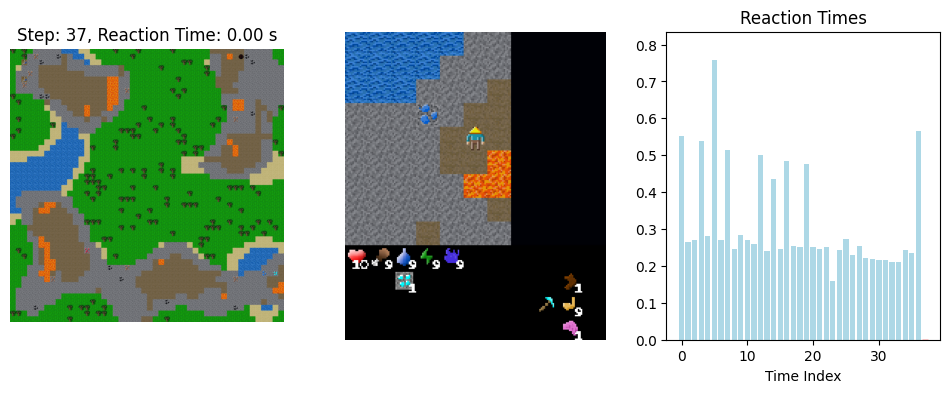

In [57]:
import craftax_utils

craftax_utils.create_episode_reaction_times_video(df.filter(eval=True, reuse=True).episodes[0])

In [59]:
df.filter(eval=True, reuse=False)['start_pos']

start_pos
str
"""[18 30]"""


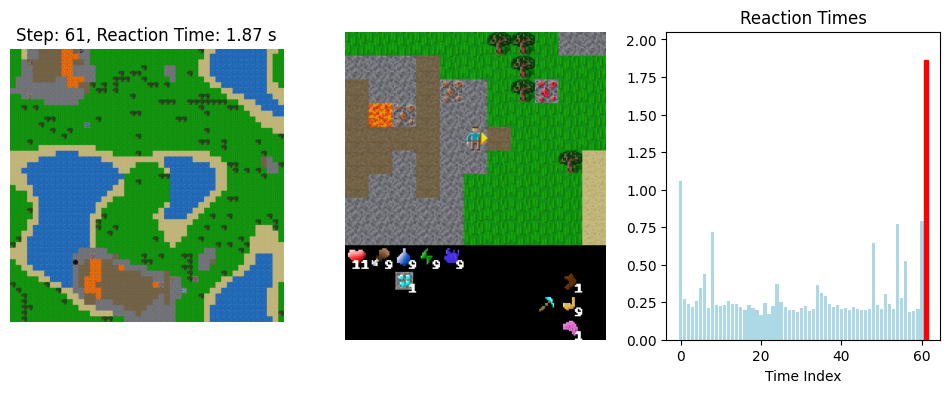

In [60]:
craftax_utils.create_episode_reaction_times_video(df.filter(eval=False, start_pos="[18 30]").episodes[0])

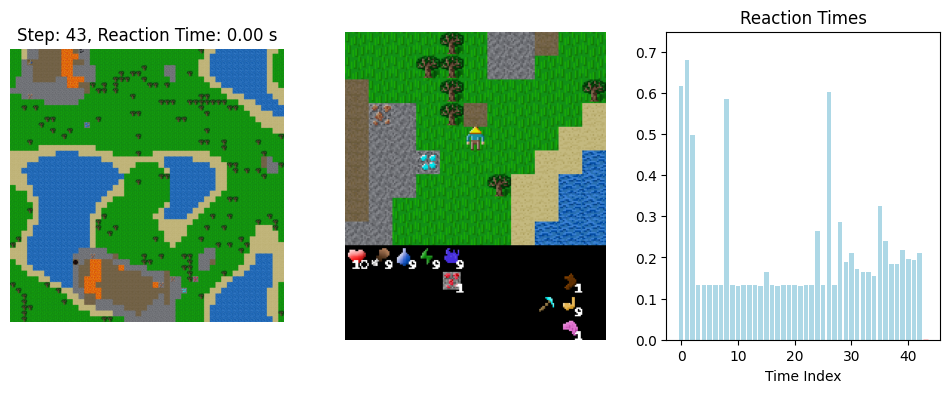

In [58]:
import craftax_utils

craftax_utils.create_episode_reaction_times_video(df.filter(eval=True, reuse=False).episodes[0])

In [43]:
file, episode_df, episode_data = await craftax_user_data.make_episode_data(
  file=file,
  example_timestep=example_timestep,
  debug=False,
  overwrite_episode_info=True,
)
if episode_df is not None and episode_data is not None:
  df = nicewebrl.DataFrame(episode_df, episode_data)

Loaded episode data from /n/holylfs06/LABS/kempner_fellow_wcarvalho/results/human_dyna_craftax/user_data/exps//user=2635592883_worker=A6MWJK1YEY5L2_name=craftax_v3-paths-r0-m0_debug=0_episode_data.bytes
Optimal length: 1
Optimal length: 1
Optimal length: 1
Optimal length: 1
Optimal length: 1
Optimal length: 1
Optimal length: 1
Optimal length: 1
Optimal length: 1
Optimal length: 1
Optimal length: 1
Optimal length: 1
Optimal length: 1
Optimal length: 1
Optimal length: 1
Optimal length: 1
Optimal length: 1
Optimal length: 1
Optimal length: 1
Optimal length: 1
Optimal length: 1
Optimal length: 1
Optimal length: 1
Optimal length: 1
Optimal length: 1
Optimal length: 1
Optimal length: 1
Optimal length: 1
Optimal length: 1
Optimal length: 1
Optimal length: 1
Optimal length: 1
Optimal length: 1
Optimal length: 1
Optimal length: 1
Optimal length: 1
Optimal length: 1
Optimal length: 1
Optimal length: 1
Optimal length: 1
Optimal length: 1
Optimal length: 1
Optimal length: 1
Optimal length: 1
Optim

In [31]:
all_mazes = df["name"].unique()
train_mazes = sorted([m for m in all_mazes if "training" in m])
test_mazes = sorted([m for m in all_mazes if "eval" in m])

# for i in range(len(train_mazes)):
name = test_mazes[0]
name = 'paths_3_eval1'
test = df.filter(name=name, eval=True)
start_pos = test["start_pos"].to_list()[0]

name = 'paths_3_training'
train = df.filter(
  name=name, room=0, eval=False, start_pos=start_pos
)
print(len(train.episodes))
test.head()

0


index,world_seed,condition,name,block,manipulation,global_episode_idx,episode_idx,eval,task,room,start_pos,user_id,age,sex,exp_name,tell_reuse,eval_map,timer,version,optimal_length,success,path_length,termination,log_first_rt,optimal_length_deviance,reuse,overlap
u32,i64,i64,str,str,str,i64,i64,bool,i64,i64,str,i64,i64,str,str,i64,i64,i64,i64,i64,f32,i64,f32,f32,i64,bool,f64
0,95,1,"""paths_3_eval1""","""reusing longer of two paths wh…","""paths""",16,1,true,10,0,"""[ 7 16]""",2635592883,39,"""Male""","""craftax_v3-paths-r0-m0""",0,0,0,3,1,1.0,27,1.0,-0.060802,26,null,null


In [35]:
train = df.filter(name=name, eval=False, start_pos=start_pos)
train.head()

index,world_seed,condition,name,block,manipulation,global_episode_idx,episode_idx,eval,task,room,start_pos,user_id,age,sex,exp_name,tell_reuse,eval_map,timer,version,optimal_length,success,path_length,termination,log_first_rt,optimal_length_deviance,reuse,overlap
u32,i64,i64,str,str,str,i64,i64,bool,i64,i64,str,i64,i64,str,str,i64,i64,i64,i64,i64,f32,i64,f32,f32,i64,bool,f64
0,95,0,"""paths_3_training""","""reusing longer of two paths wh…","""paths""",0,1,false,22,1,"""[ 7 16]""",2635592883,39,"""Male""","""craftax_v3-paths-r0-m0""",0,0,0,3,1,1.0,32,1.0,0.36326,31,null,null
1,95,0,"""paths_3_training""","""reusing longer of two paths wh…","""paths""",9,10,false,22,1,"""[ 7 16]""",2635592883,39,"""Male""","""craftax_v3-paths-r0-m0""",0,0,0,3,1,1.0,16,1.0,1.911911,15,null,null
2,95,0,"""paths_3_training""","""reusing longer of two paths wh…","""paths""",11,12,false,22,1,"""[ 7 16]""",2635592883,39,"""Male""","""craftax_v3-paths-r0-m0""",0,0,0,3,1,1.0,14,1.0,1.250191,13,null,null


In [68]:
df_added = craftax_user_data.add_reuse_columns(df, overlap_threshold=0.15)

In [69]:
not_reuse = df_added.filter(reuse=False)
not_reuse.head()

index,world_seed,condition,name,block,manipulation,global_episode_idx,episode_idx,eval,task,room,start_pos,user_id,age,sex,exp_name,tell_reuse,eval_map,timer,version,optimal_length,success,path_length,termination,log_first_rt,log_avg_rt,log_total_rt,log_avg_post_rt,log_max_rt,log_max_post_rt,log_max_init_post_rt,log_max_end_rt,log_max_final_rt,optimal_length_deviance,reuse,overlap
u32,i64,i64,str,str,str,i64,i64,bool,i64,i64,str,i64,i64,str,str,i64,i64,i64,i64,i64,f32,i64,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,i64,bool,f64


In [70]:
reused = df_added.filter(reuse=True)
reused.head()

index,world_seed,condition,name,block,manipulation,global_episode_idx,episode_idx,eval,task,room,start_pos,user_id,age,sex,exp_name,tell_reuse,eval_map,timer,version,optimal_length,success,path_length,termination,log_first_rt,log_avg_rt,log_total_rt,log_avg_post_rt,log_max_rt,log_max_post_rt,log_max_init_post_rt,log_max_end_rt,log_max_final_rt,optimal_length_deviance,reuse,overlap
u32,i64,i64,str,str,str,i64,i64,bool,i64,i64,str,i64,i64,str,str,i64,i64,i64,i64,i64,f32,i64,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,i64,bool,f64
0,15,1,"""paths_1_eval1""","""reusing longer of two paths wh…","""paths""",17,1,true,21,0,"""[24 24]""",4172656471,35,"""Female""","""craftax_v1-paths-r0-m1""",0,1,0,1,1,1.0,53,1.0,0.708533,-1.23248,-65.321426,-1.269807,0.708533,-0.006008,-0.006008,-0.970193,-0.648155,52,true,0.244898
1,20,1,"""paths_2_eval1""","""reusing longer of two paths wh…","""paths""",34,1,true,22,0,"""[18 30]""",4172656471,35,"""Female""","""craftax_v1-paths-r0-m1""",0,1,0,1,1,1.0,45,1.0,0.359079,-1.486778,-66.905022,-1.52873,0.359079,-0.49921,-0.49921,-0.731867,-0.731867,44,true,0.622222
2,3,1,"""paths_0_eval1""","""reusing longer of two paths wh…","""paths""",51,1,true,10,0,"""[28 25]""",4172656471,35,"""Female""","""craftax_v1-paths-r0-m1""",0,1,0,1,1,1.0,38,1.0,0.05355,-1.516469,-57.625835,-1.558902,0.05355,-0.848609,-0.848609,-0.928844,-0.928844,37,true,0.529412
3,95,1,"""paths_3_eval1""","""reusing longer of two paths wh…","""paths""",68,1,true,10,0,"""[ 7 16]""",4172656471,35,"""Female""","""craftax_v1-paths-r0-m1""",0,1,0,1,1,1.0,42,1.0,-1.093595,-1.606121,-67.4571,-1.618622,-0.918769,-0.918769,-1.15833,-0.918769,-0.918769,41,true,0.342105


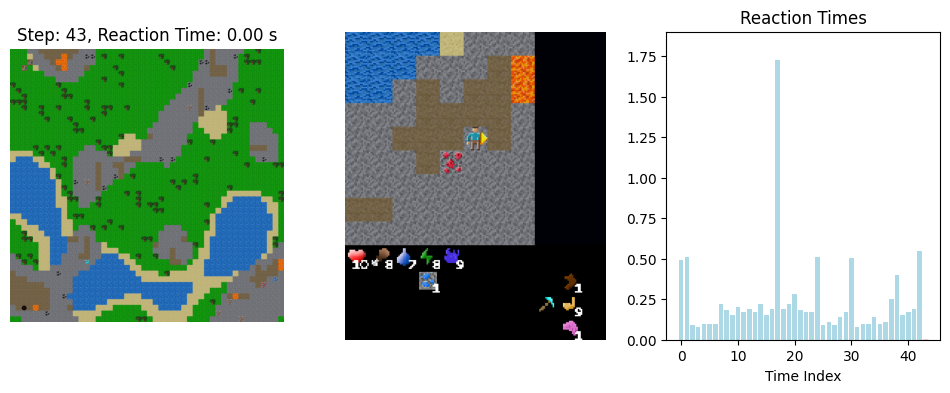

In [58]:
import craftax_utils

craftax_utils.create_episode_reaction_times_video(reused.episodes[0])

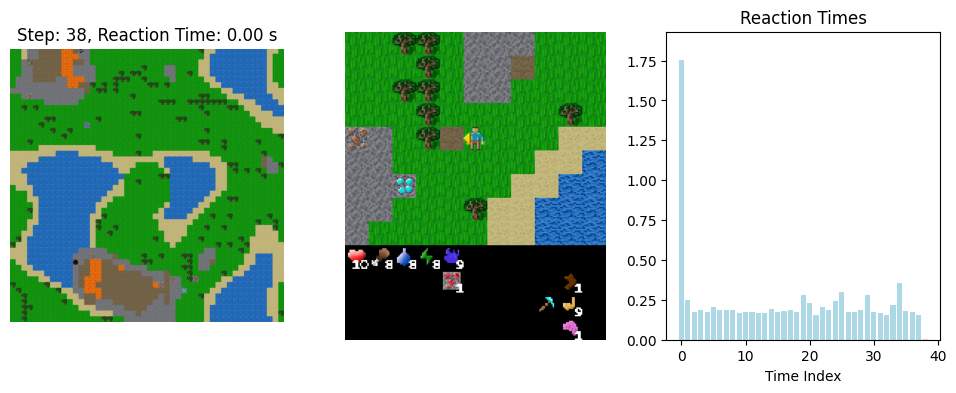

In [59]:
craftax_utils.create_episode_reaction_times_video(not_reuse.episodes[0])

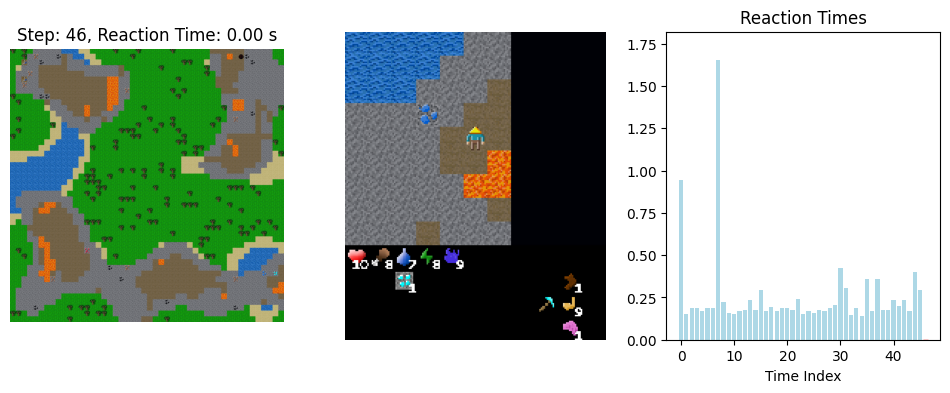

In [60]:
craftax_utils.create_episode_reaction_times_video(not_reuse.episodes[1])